---

## 1. Imports & Environment Setup

In [1]:
# Core data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# File handling and utilities
from pathlib import Path
import uuid
from datetime import datetime, timezone
import json

# Parquet support
import pyarrow.parquet as pq

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print(" Environment setup complete")
print(f" pandas: {pd.__version__}")
print(f" numpy: {np.__version__}")

 Environment setup complete
 pandas: 2.3.3
 numpy: 2.3.5


---

## 2. Download / Load Dataset

### Dataset Structure

The RetailRocket dataset consists of events.csv.gz (user behavior), category_tree.csv, and item properties files. This notebook focuses on events data.

### Download Instructions

Download from: https://www.kaggle.com/retailrocket/ecommerce-dataset
Place events.csv.gz in: `notebooks/artifacts/external/retailrocket/`

In [2]:
# Define data paths
DATA_DIR = Path('artifacts/external/retailrocket')
EVENTS_FILE = DATA_DIR / 'events.csv.gz'

# Check if file exists
if not EVENTS_FILE.exists():
 print(f"Error: ERROR: {EVENTS_FILE} not found!")
 print("\nPlease download the RetailRocket dataset:")
 print("1. Visit: https://www.kaggle.com/retailrocket/ecommerce-dataset")
 print(f"2. Download events.csv.gz")
 print(f"3. Place it in: {DATA_DIR.absolute()}")
 raise FileNotFoundError(f"Dataset not found: {EVENTS_FILE}")

print(f" Found dataset: {EVENTS_FILE}")
print(f" Loading data...")

# Load the dataset
df_raw = pd.read_csv(EVENTS_FILE, compression='gzip')

print(f"\n Loaded {len(df_raw):,} events")
print(f" Shape: {df_raw.shape}")
print(f" Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

 Found dataset: artifacts\external\retailrocket\events.csv.gz
 Loading data...

 Loaded 2,756,101 events
 Shape: (2756101, 5)
 Memory usage: 223.90 MB


In [3]:
# Display first few rows
print("First 10 rows:")
df_raw.head(10)

First 10 rows:


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN
5,1433224086234,972639,view,22556,NaN
6,1433221923240,810725,view,443030,NaN
7,1433223291897,794181,view,439202,NaN
8,1433220899221,824915,view,428805,NaN
9,1433221204592,339335,view,82389,NaN


In [4]:
# Display dataset info
print("Dataset Info:")
df_raw.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


### Column Explanations

The RetailRocket events dataset has 5 columns:

| Column | Type | Description |
|--------|------|-------------|
| `timestamp` | int64 | Unix timestamp (milliseconds since epoch) |
| `visitorid` | int64 | Unique user identifier |
| `event` | object | Event type: `view`, `addtocart`, `transaction` |
| `itemid` | int64 | Product identifier |
| `transactionid` | float64 | Transaction/session ID (null for views) |
- Timestamps are in milliseconds (need conversion to datetime)
- User/product IDs are integers (need to convert to strings for consistency)

---

## 3. Event Type Mapping

RetailRocket uses different event names than our internal schema. We need to map:

| RetailRocket | Internal Schema |
|--------------|----------------|
| `view` | `view` |
| `addtocart` | `add_to_cart` |
| `transaction` | `purchase` |

We'll also check for any unsupported event types and drop them.

In [5]:
# Check unique event types
print("Event types in dataset:")
print(df_raw['event'].value_counts())
print(f"\nTotal unique event types: {df_raw['event'].nunique()}")

Event types in dataset:
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

Total unique event types: 3


In [6]:
# Create a mapping for event types
EVENT_TYPE_MAPPING = {
 'view': 'view',
 'addtocart': 'add_to_cart',
 'transaction': 'purchase'
}

# Check for unmapped event types
unmapped_events = df_raw[~df_raw['event'].isin(EVENT_TYPE_MAPPING.keys())]
if len(unmapped_events) > 0:
 print(f"Warning: Found {len(unmapped_events):,} unmapped events:")
 print(unmapped_events['event'].value_counts())
else:
 print(" All event types are recognized")

# Filter to only supported events
df_filtered = df_raw[df_raw['event'].isin(EVENT_TYPE_MAPPING.keys())].copy()

print(f"\n Events after filtering: {len(df_filtered):,}")
print(f"📉 Dropped: {len(df_raw) - len(df_filtered):,} events")

# Apply mapping
df_filtered['event_type'] = df_filtered['event'].map(EVENT_TYPE_MAPPING)

print("\nMapped event types:")
print(df_filtered['event_type'].value_counts())

 All event types are recognized

 Events after filtering: 2,756,101
📉 Dropped: 0 events

Mapped event types:
event_type
view           2664312
add_to_cart      69332
purchase         22457
Name: count, dtype: int64


---

## 4. Schema Alignment

### Internal Event Schema

Our system uses a consistent event schema across all services:

```python
{
 "event_id": "uuid4-string", # Unique event identifier
 "event_type": "view|add_to_cart|purchase", # Action type
 "user_id": "string", # User identifier
 "session_id": "uuid4-string", # Session identifier
 "product_id": "string", # Product identifier
 "ts": "2024-01-01T00:00:00+00:00", # ISO 8601 timestamp (UTC)
 "properties": { # Additional metadata
 "source": "retailrocket",
 "original_timestamp": 1234567890
 }
}
```

### Transformation Strategy

1. **event_id**: Generate UUID v4 for each event
2. **event_type**: Already mapped in previous step
3. **user_id**: Convert `visitorid` to string
4. **session_id**: 
 - Use `transactionid` if present (converted to string)
 - Generate UUID v4 per user-day session if missing
5. **product_id**: Convert `itemid` to string
6. **ts**: Convert Unix milliseconds to ISO 8601 UTC timestamp
7. **properties**: Store source and original timestamp

In [7]:
# Start with filtered dataframe
df_aligned = df_filtered.copy()

print("Transforming data to internal schema...\n")

# 1. Generate event_id (UUID v4)
print("1. Generating event_id...")
df_aligned['event_id'] = [str(uuid.uuid4()) for _ in range(len(df_aligned))]

# 2. event_type already mapped
print("2. event_type: Already mapped")

# 3. user_id: Convert visitorid to string
print("3. Converting user_id...")
df_aligned['user_id'] = df_aligned['visitorid'].astype(str)

# 4. session_id: Use transactionid if present, else generate per user-day
print("4. Generating session_id...")

def generate_session_id(row):
    """Generate session_id based on transactionid or user-day"""
    if pd.notna(row['transactionid']):
        # Use transactionid if present
        return str(int(row['transactionid']))
    else:
        # Generate session based on user_id and date
        # Convert timestamp (ms) to date
        date_str = datetime.fromtimestamp(row['timestamp'] / 1000, tz=timezone.utc).strftime('%Y-%m-%d')
        # Create deterministic session_id per user-day
        return f"session_{row['user_id']}_{date_str}"

df_aligned['session_id'] = df_aligned.apply(generate_session_id, axis=1)

# 5. product_id: Convert itemid to string
print("5. Converting product_id...")
df_aligned['product_id'] = df_aligned['itemid'].astype(str)

# 6. ts: Convert Unix milliseconds to ISO 8601 UTC
print("6. Converting timestamps to ISO 8601...")
df_aligned['ts'] = pd.to_datetime(df_aligned['timestamp'], unit='ms', utc=True).dt.strftime('%Y-%m-%dT%H:%M:%S%z')

# 7. properties: Store metadata as JSON
print("7. Creating properties field...")
df_aligned['properties'] = df_aligned.apply(
    lambda row: json.dumps({'source': 'retailrocket', 'original_timestamp_ms': int(row['timestamp'])}),
    axis=1
)

# Select final columns
INTERNAL_SCHEMA_COLUMNS = ['event_id', 'event_type', 'user_id', 'session_id', 'product_id', 'ts', 'properties']
df_final = df_aligned[INTERNAL_SCHEMA_COLUMNS].copy()

print(f"\nTransformation complete!")
print(f"Final schema: {list(df_final.columns)}")
print(f"Total rows: {len(df_final):,}")

Transforming data to internal schema...

1. Generating event_id...
2. event_type: Already mapped
3. Converting user_id...
4. Generating session_id...
5. Converting product_id...
6. Converting timestamps to ISO 8601...
7. Creating properties field...

Transformation complete!
Final schema: ['event_id', 'event_type', 'user_id', 'session_id', 'product_id', 'ts', 'properties']
Total rows: 2,756,101


In [8]:
# Select only the internal schema columns
INTERNAL_SCHEMA_COLUMNS = [
 'event_id',
 'event_type',
 'user_id',
 'session_id',
 'product_id',
 'ts',
 'properties'
]

df_final = df_aligned[INTERNAL_SCHEMA_COLUMNS].copy()

print("Final schema:")
print(df_final.dtypes)
print(f"\n Final dataset shape: {df_final.shape}")
print(f"\nFirst 5 rows:")
df_final.head()

Final schema:
event_id      object
event_type    object
user_id       object
session_id    object
product_id    object
ts            object
properties    object
dtype: object

 Final dataset shape: (2756101, 7)

First 5 rows:


,event_id,event_type,user_id,session_id,product_id,ts,properties
0,a8240f97-c177-456c-98a3-62ed98368fda,view,257597,session_257597_2015-06-02,355908,2015-06-02T05:02:12+0000,"{""source"": ""retailrocket"", ""original_timestamp..."
1,09c898e4-684a-436f-8768-21ac6bd0a6e4,view,992329,session_992329_2015-06-02,248676,2015-06-02T05:50:14+0000,"{""source"": ""retailrocket"", ""original_timestamp..."
2,f9b22adf-b00a-40ea-bbed-254959ca9ebc,view,111016,session_111016_2015-06-02,318965,2015-06-02T05:13:19+0000,"{""source"": ""retailrocket"", ""original_timestamp..."
3,509647d1-ade9-426b-a4e4-4e6b3b06bfd7,view,483717,session_483717_2015-06-02,253185,2015-06-02T05:12:35+0000,"{""source"": ""retailrocket"", ""original_timestamp..."
4,3a11c0f9-0b0a-4c3a-a3dc-e2662c938830,view,951259,session_951259_2015-06-02,367447,2015-06-02T05:02:17+0000,"{""source"": ""retailrocket"", ""original_timestamp..."


---

## 5. Data Quality Checks

Before proceeding with analysis, let's validate data quality.

In [17]:
print("Data Quality Report\n")

# 1. Null checks
print("1. NULL VALUES:")
null_counts = df_final.isnull().sum()
if null_counts.sum() == 0:
    print("   No null values found")
else:
    print(null_counts[null_counts > 0])

# 2. Event type distribution
print("\n2. EVENT TYPE DISTRIBUTION:")
event_counts = df_final['event_type'].value_counts()
print(event_counts)
print(f"\n   Total events: {len(df_final):,}")

# 3. Unique users
print("\n3. UNIQUE USERS:")
unique_users = df_final['user_id'].nunique()
print(f"   {unique_users:,} unique users")
print(f"   Avg events per user: {len(df_final) / unique_users:.2f}")

# 4. Unique products
print("\n4. UNIQUE PRODUCTS:")
unique_products = df_final['product_id'].nunique()
print(f"   {unique_products:,} unique products")
print(f"   Avg events per product: {len(df_final) / unique_products:.2f}")

# 5. Unique sessions
print("\n5. UNIQUE SESSIONS:")
unique_sessions = df_final['session_id'].nunique()
print(f"   {unique_sessions:,} unique sessions")
print(f"   Avg events per session: {len(df_final) / unique_sessions:.2f}")

# 6. Time range
print("\n6. TIME RANGE:")
df_final['ts_parsed'] = pd.to_datetime(df_final['ts'])
print(f"   Start: {df_final['ts_parsed'].min()}")
print(f"   End: {df_final['ts_parsed'].max()}")
print(f"   Duration: {(df_final['ts_parsed'].max() - df_final['ts_parsed'].min()).days} days")

Data Quality Report

1. NULL VALUES:
   No null values found

2. EVENT TYPE DISTRIBUTION:
event_type
view           2664312
add_to_cart      69332
purchase         22457
Name: count, dtype: int64

   Total events: 2,756,101

3. UNIQUE USERS:
   1,407,580 unique users
   Avg events per user: 1.96

4. UNIQUE PRODUCTS:
   235,061 unique products
   Avg events per product: 11.73

5. UNIQUE SESSIONS:
   1,666,974 unique sessions
   Avg events per session: 1.65

6. TIME RANGE:
   Start: 2015-05-03 03:00:04+00:00
   End: 2015-09-18 02:59:47+00:00
   Duration: 137 days


---

## 6. Exploratory Data Analysis (EDA)

Now let's explore the data to understand user behavior patterns.

### 6.1 Event Type Distribution

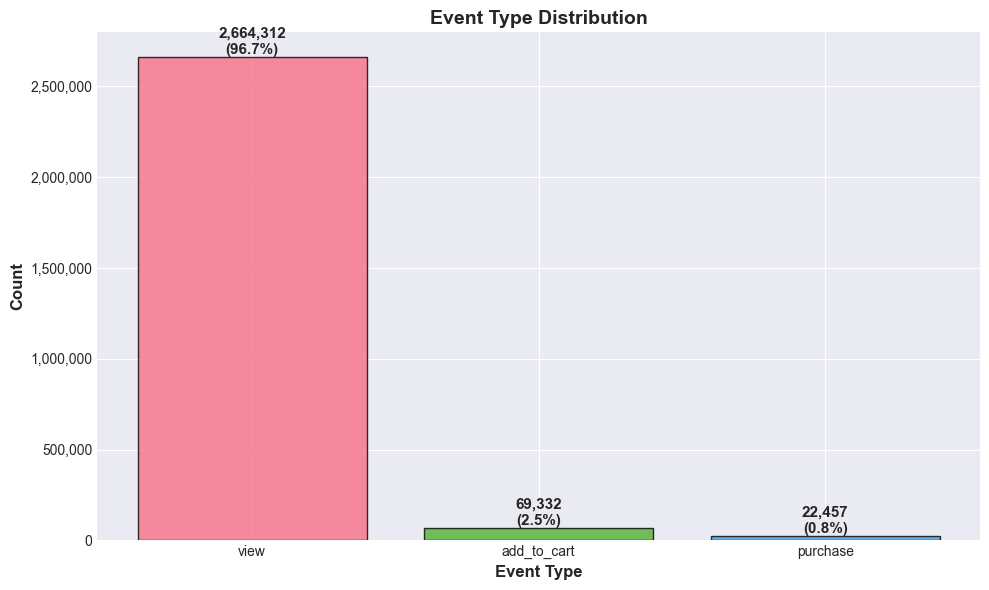


 Insights:
 • Views dominate the dataset (96.7%)
 • Conversion funnel: View → Add to Cart → Purchase
 • Add-to-cart rate: 2.60%
 • Purchase rate: 0.84%


In [10]:
# Event type distribution
fig, ax = plt.subplots(figsize=(10, 6))

event_counts = df_final['event_type'].value_counts()
colors = sns.color_palette('husl', len(event_counts))

bars = ax.bar(event_counts.index, event_counts.values, color=colors, edgecolor='black', alpha=0.8)

# Add value labels on bars
for bar in bars:
 height = bar.get_height()
 ax.text(bar.get_x() + bar.get_width()/2., height,
 f'{int(height):,}\n({height/len(df_final)*100:.1f}%)',
 ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Event Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Event Type Distribution', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print("\n Insights:")
print(f" • Views dominate the dataset ({event_counts['view']/len(df_final)*100:.1f}%)")
print(f" • Conversion funnel: View → Add to Cart → Purchase")
print(f" • Add-to-cart rate: {event_counts.get('add_to_cart', 0)/event_counts['view']*100:.2f}%")
print(f" • Purchase rate: {event_counts.get('purchase', 0)/event_counts['view']*100:.2f}%")

### 6.2 Top 20 Most Interacted Products

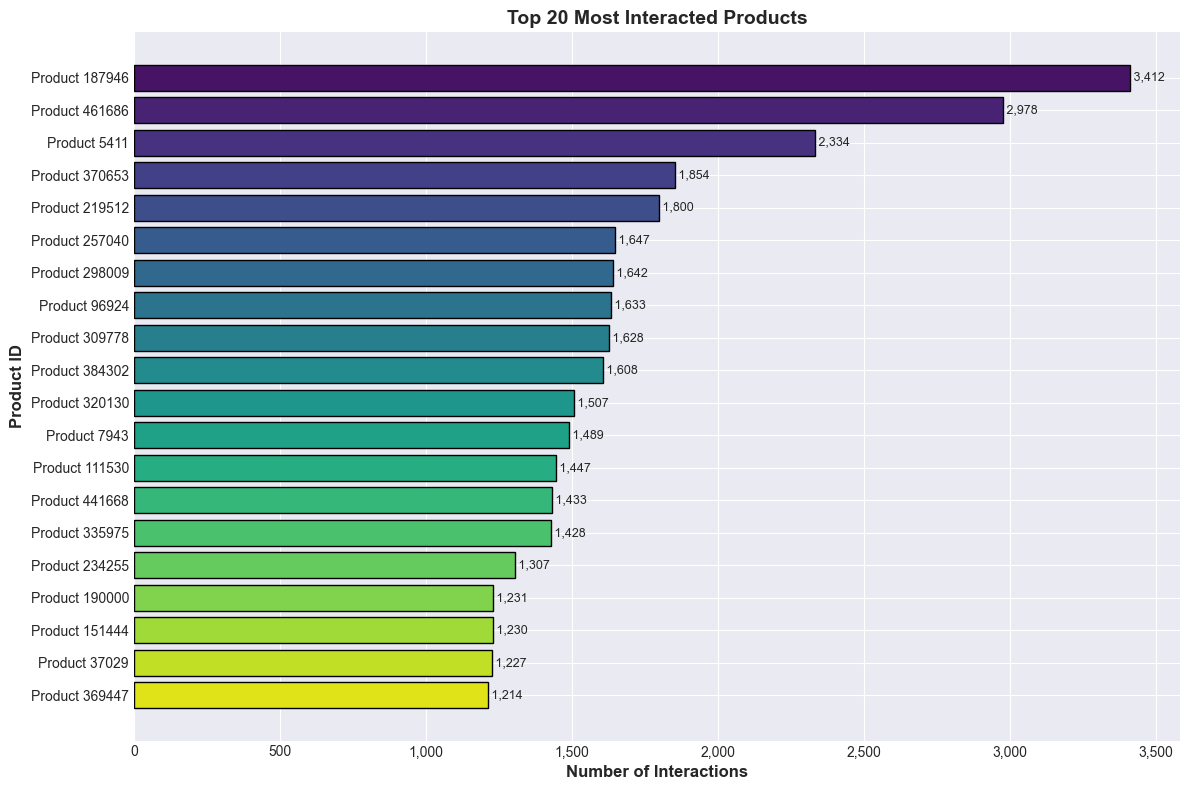


 Insights:
 • Top product has 3,412 interactions
 • Top 20 products account for 1.24% of all events
 • Strong power-law distribution (few products dominate)


In [11]:
# Top 20 products by interaction count
top_products = df_final['product_id'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(range(len(top_products)), top_products.values, color=sns.color_palette('viridis', len(top_products)), edgecolor='black')
ax.set_yticks(range(len(top_products)))
ax.set_yticklabels([f"Product {pid}" for pid in top_products.index])
ax.invert_yaxis()

# Add value labels
for i, (bar, value) in enumerate(zip(bars, top_products.values)):
 ax.text(value, i, f' {value:,}', va='center', fontsize=9)

ax.set_xlabel('Number of Interactions', fontsize=12, fontweight='bold')
ax.set_ylabel('Product ID', fontsize=12, fontweight='bold')
ax.set_title('Top 20 Most Interacted Products', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print("\n Insights:")
print(f" • Top product has {top_products.iloc[0]:,} interactions")
print(f" • Top 20 products account for {top_products.sum()/len(df_final)*100:.2f}% of all events")
print(f" • Strong power-law distribution (few products dominate)")

### 6.3 Interaction Timeline

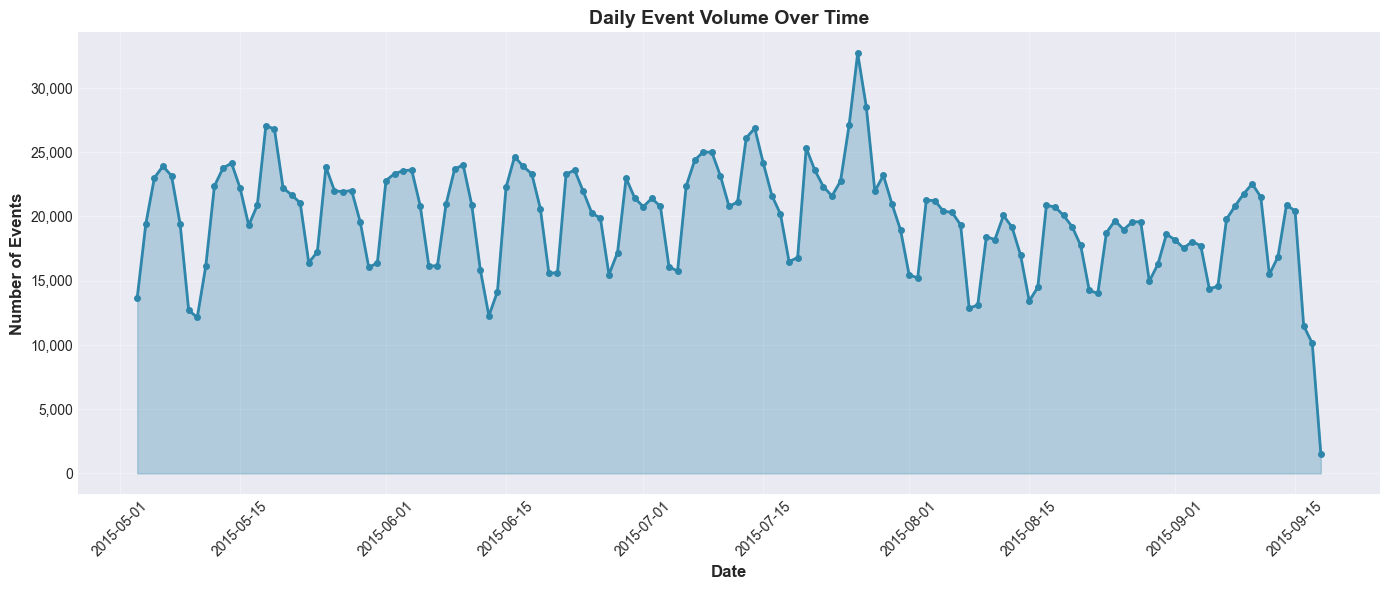


 Insights:
 • Average daily events: 19,828
 • Peak day: 2015-07-26 with 32,703 events
 • Minimum day: 2015-09-18 with 1,528 events
 • Check for seasonality patterns or data collection artifacts


In [12]:
# Events over time (daily)
df_final['date'] = df_final['ts_parsed'].dt.date
daily_events = df_final.groupby('date').size()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(daily_events.index, daily_events.values, linewidth=2, color='#2E86AB', marker='o', markersize=4)
ax.fill_between(daily_events.index, daily_events.values, alpha=0.3, color='#2E86AB')

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Events', fontsize=12, fontweight='bold')
ax.set_title('Daily Event Volume Over Time', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n Insights:")
print(f" • Average daily events: {daily_events.mean():,.0f}")
print(f" • Peak day: {daily_events.idxmax()} with {daily_events.max():,} events")
print(f" • Minimum day: {daily_events.idxmin()} with {daily_events.min():,} events")
print(f" • Check for seasonality patterns or data collection artifacts")

### 6.4 Events Per User Distribution

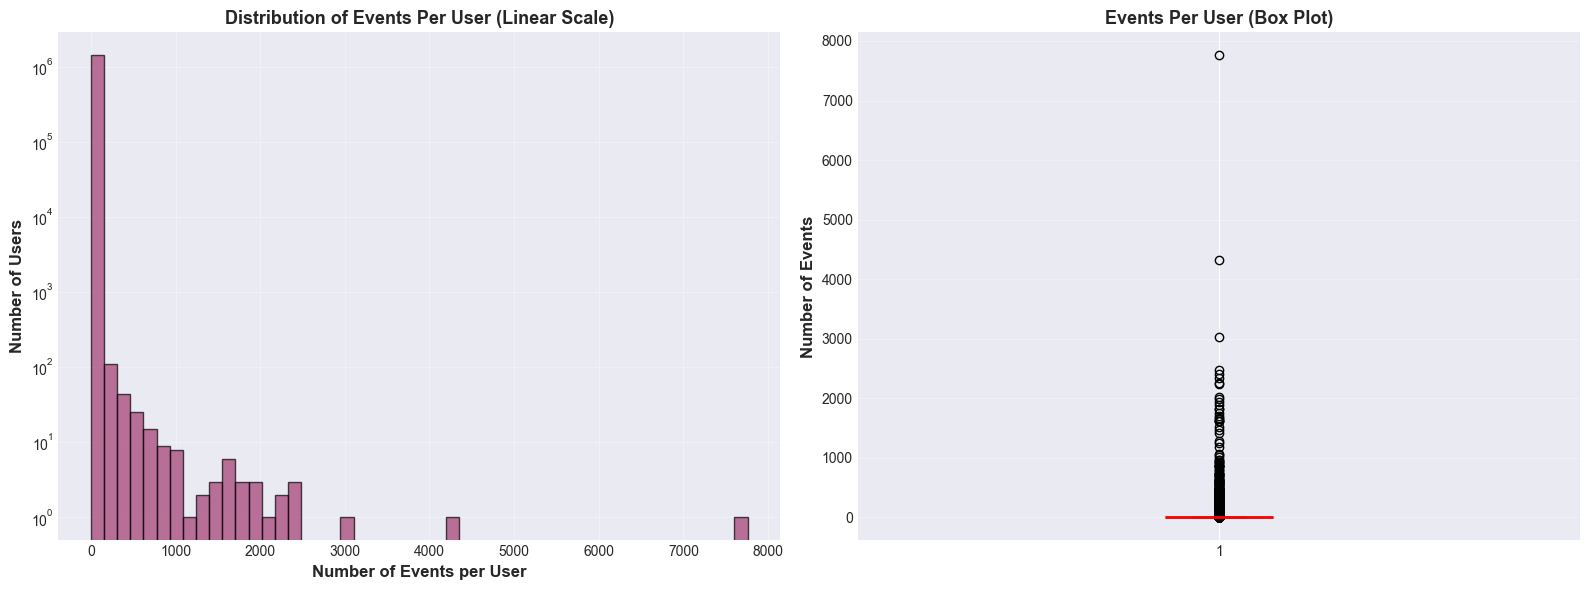


 Insights:
 • Mean events per user: 1.96
 • Median events per user: 1
 • Max events per user: 7,757
 • 95th percentile: 5 events
 • Heavy-tailed distribution: Some users are very active, most are casual


In [13]:
# Distribution of events per user
events_per_user = df_final['user_id'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram (log scale)
axes[0].hist(events_per_user.values, bins=50, color='#A23B72', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Events per User', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Users', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Events Per User (Linear Scale)', fontsize=13, fontweight='bold')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(events_per_user.values, vert=True, patch_artist=True,
 boxprops=dict(facecolor='#F18F01', alpha=0.7),
 medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Number of Events', fontsize=12, fontweight='bold')
axes[1].set_title('Events Per User (Box Plot)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n Insights:")
print(f" • Mean events per user: {events_per_user.mean():.2f}")
print(f" • Median events per user: {events_per_user.median():.0f}")
print(f" • Max events per user: {events_per_user.max():,}")
print(f" • 95th percentile: {events_per_user.quantile(0.95):.0f} events")
print(f" • Heavy-tailed distribution: Some users are very active, most are casual")

### 6.5 User Engagement Segmentation

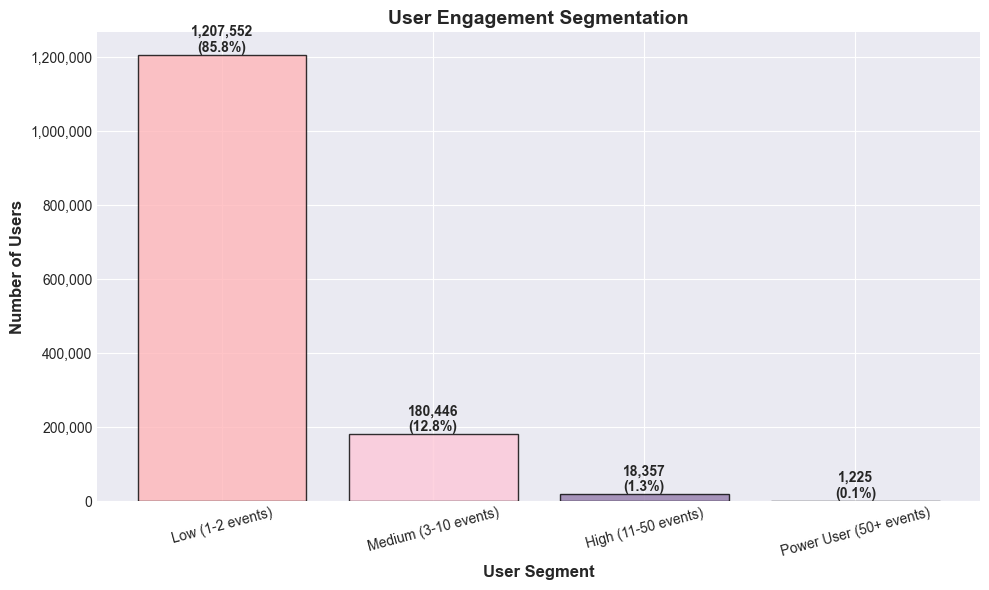


 Insights:
 • Most users are in the 'Low (1-2 events)' segment
 • Power users (1,225) drive significant activity
 • Consider personalization strategies per segment


In [14]:
# Segment users by engagement level
def segment_user(event_count):
 if event_count <= 2:
     return 'Low (1-2 events)'
 elif event_count <= 10:
     return 'Medium (3-10 events)'
 elif event_count <= 50:
     return 'High (11-50 events)'
 else:
     return 'Power User (50+ events)'

user_segments = events_per_user.apply(segment_user).value_counts()

# Reorder for logical display
segment_order = ['Low (1-2 events)', 'Medium (3-10 events)', 'High (11-50 events)', 'Power User (50+ events)']
user_segments = user_segments.reindex(segment_order)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#FFB6B9', '#FEC8D8', '#957DAD', '#5E548E']
bars = ax.bar(user_segments.index, user_segments.values, color=colors, edgecolor='black', alpha=0.8)

# Add value labels
for bar in bars:
 height = bar.get_height()
 ax.text(bar.get_x() + bar.get_width()/2., height,
 f'{int(height):,}\n({height/user_segments.sum()*100:.1f}%)',
 ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('User Segment', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Users', fontsize=12, fontweight='bold')
ax.set_title('User Engagement Segmentation', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\n Insights:")
print(f" • Most users are in the '{user_segments.idxmax()}' segment")
print(f" • Power users ({user_segments['Power User (50+ events)']:,}) drive significant activity")
print(f" • Consider personalization strategies per segment")

---

## 7. Save Cleaned Dataset

Save the schema-aligned dataset as Parquet for efficient storage and fast loading in future notebooks.

In [15]:
# Define output path
OUTPUT_DIR = Path('artifacts/external/retailrocket')
OUTPUT_FILE = OUTPUT_DIR / 'events.parquet'

# Ensure directory exists
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f" Saving cleaned dataset to: {OUTPUT_FILE}")
print(f" Rows: {len(df_final):,}")
print(f" Columns: {list(df_final.columns)}\n")

# Drop temporary columns used for analysis
df_to_save = df_final[INTERNAL_SCHEMA_COLUMNS].copy()

# Save as Parquet
df_to_save.to_parquet(OUTPUT_FILE, index=False, compression='snappy', engine='pyarrow')

print(f" Dataset saved successfully!")
print(f" File size: {OUTPUT_FILE.stat().st_size / 1024**2:.2f} MB")

 Saving cleaned dataset to: artifacts\external\retailrocket\events.parquet
 Rows: 2,756,101
 Columns: ['event_id', 'event_type', 'user_id', 'session_id', 'product_id', 'ts', 'properties', 'ts_parsed', 'date']

 Dataset saved successfully!
 File size: 185.51 MB


In [16]:
# Verify saved file
print(" Verifying saved Parquet file...\n")

# Load and check schema
df_verify = pd.read_parquet(OUTPUT_FILE)

print(f" Successfully loaded {len(df_verify):,} rows")
print(f"\nSchema:")
print(df_verify.dtypes)
print(f"\nFirst 3 rows:")
df_verify.head(3)

 Verifying saved Parquet file...

 Successfully loaded 2,756,101 rows

Schema:
event_id      object
event_type    object
user_id       object
session_id    object
product_id    object
ts            object
properties    object
dtype: object

First 3 rows:


,event_id,event_type,user_id,session_id,product_id,ts,properties
0,a8240f97-c177-456c-98a3-62ed98368fda,view,257597,session_257597_2015-06-02,355908,2015-06-02T05:02:12+0000,"{""source"": ""retailrocket"", ""original_timestamp..."
1,09c898e4-684a-436f-8768-21ac6bd0a6e4,view,992329,session_992329_2015-06-02,248676,2015-06-02T05:50:14+0000,"{""source"": ""retailrocket"", ""original_timestamp..."
2,f9b22adf-b00a-40ea-bbed-254959ca9ebc,view,111016,session_111016_2015-06-02,318965,2015-06-02T05:13:19+0000,"{""source"": ""retailrocket"", ""original_timestamp..."
